# Model Results

Visual proof of the fraud detection and expense forecasting models documented in the [fraud detection guide](../docs/3-ml-fraud-detection.md) and [expense forecast guide](../docs/4-ml-expense-forecast.md).

This notebook retrains both models from the local DuckDB mart, evaluates them on a held-out temporal split, and produces the charts that corroborate the metrics from the experiment log.

In [1]:
import sys, os

# Run from repo root so all relative paths in src/ modules work
os.chdir(os.path.join(os.path.dirname(os.path.abspath(".")), ""))
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.metrics import (
    average_precision_score, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay,
    r2_score, mean_absolute_error, mean_squared_error,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120
FRAUD_COLOR = "#e74c3c"
LEGIT_COLOR = "#3498db"
FORECAST_COLOR = "#27ae60"

## Part A: Fraud Detection

We retrain the LightGBM + Focal Loss model on the DuckDB mart with an 85/15 temporal split, then visualize the results on the validation set.

In [2]:
from src.models.train_model import (
    FEATURE_COLS, CATEGORICAL_COLS, TE_COLS,
    load_labels, load_features,
    target_encode_oof, target_encode_apply, prepare_features,
    focal_loss_objective, focal_loss_eval,
)
import duckdb, lightgbm as lgb

# Load data from DuckDB mart
labels = load_labels()
con = duckdb.connect("data/dbt_output/caixabank.duckdb", read_only=True)
train_df = load_features(con, list(labels.keys()), "training")
con.close()
train_df["label"] = train_df["transaction_id"].map(labels)
train_df = train_df.dropna(subset=["label"]).sort_values("transaction_date").reset_index(drop=True)

# Target encoding
for col in TE_COLS:
    train_df[f"{col}_te"] = target_encode_oof(train_df, col, "label")
train_df = prepare_features(train_df)

# Temporal split 85/15
split_idx = int(len(train_df) * 0.85)
X_train, y_train = train_df.iloc[:split_idx][FEATURE_COLS], train_df.iloc[:split_idx]["label"].astype(int)
X_val, y_val = train_df.iloc[split_idx:][FEATURE_COLS], train_df.iloc[split_idx:]["label"].astype(int)

# Train
model = lgb.LGBMClassifier(
    objective=focal_loss_objective, n_estimators=1000, learning_rate=0.05,
    max_depth=6, num_leaves=63, min_child_samples=300, subsample=0.8,
    colsample_bytree=0.8, reg_alpha=0.5, reg_lambda=2.0, random_state=42, verbose=-1,
)
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric=focal_loss_eval,
          callbacks=[lgb.early_stopping(100, verbose=False)])

# Score validation set (sigmoid on raw logits)
val_proba = 1.0 / (1.0 + np.exp(-model.predict(X_val, raw_score=True)))
auprc = average_precision_score(y_val, val_proba)
print(f"Validation: {len(X_val):,} transactions, {y_val.mean():.4%} fraud rate")
print(f"AUPRC: {auprc:.4f}")

Loaded 8,914,963 rows for training


Validation: 1,337,245 transactions, 0.1760% fraud rate
AUPRC: 0.5988


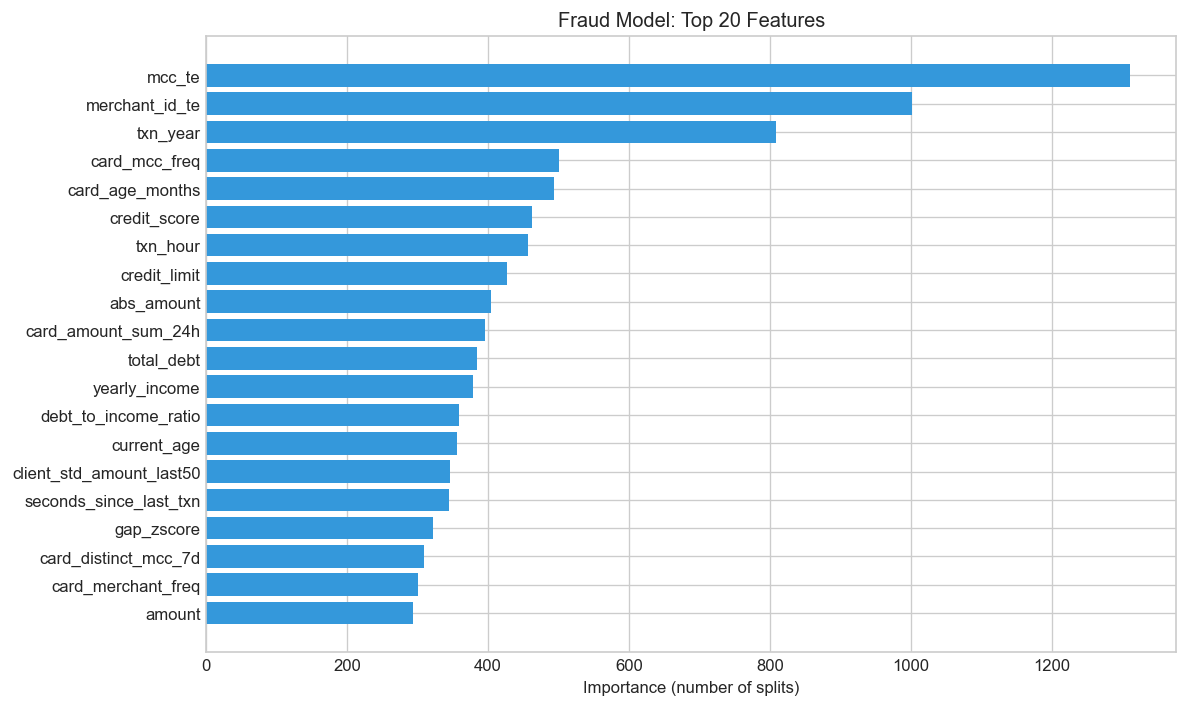

In [3]:
# Feature importance (top 20)
importance = sorted(zip(FEATURE_COLS, model.feature_importances_), key=lambda x: x[1], reverse=True)
top20 = importance[:20]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh([f[0] for f in reversed(top20)], [f[1] for f in reversed(top20)], color=LEGIT_COLOR)
ax.set_xlabel("Importance (number of splits)")
ax.set_title("Fraud Model: Top 20 Features")
plt.tight_layout()
plt.show()

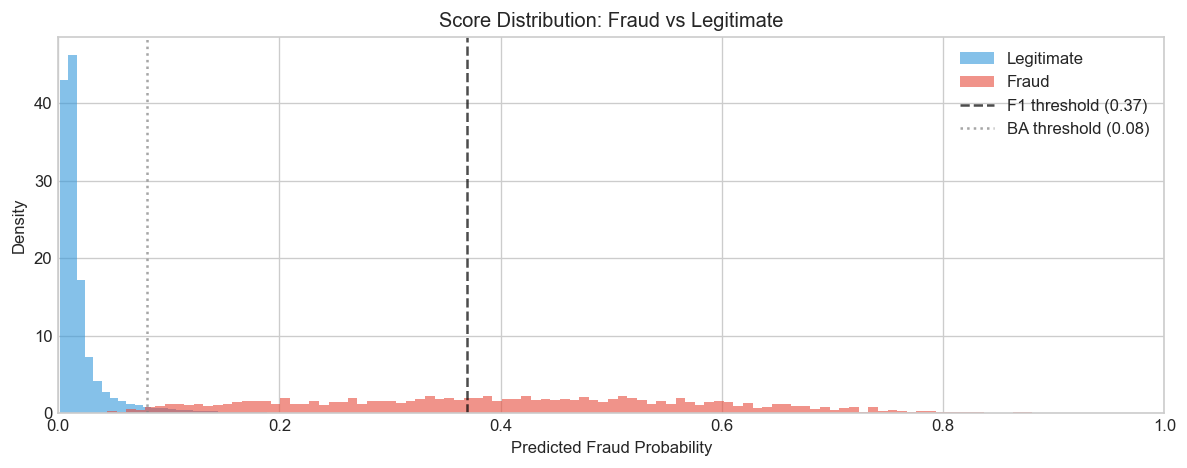

In [4]:
# Score distribution: fraud vs legitimate
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(val_proba[y_val == 0], bins=100, alpha=0.6, color=LEGIT_COLOR, label="Legitimate", density=True)
ax.hist(val_proba[y_val == 1], bins=100, alpha=0.6, color=FRAUD_COLOR, label="Fraud", density=True)
ax.axvline(0.37, color="black", linestyle="--", alpha=0.7, label="F1 threshold (0.37)")
ax.axvline(0.08, color="gray", linestyle=":", alpha=0.7, label="BA threshold (0.08)")
ax.set_xlabel("Predicted Fraud Probability")
ax.set_ylabel("Density")
ax.set_title("Score Distribution: Fraud vs Legitimate")
ax.legend()
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

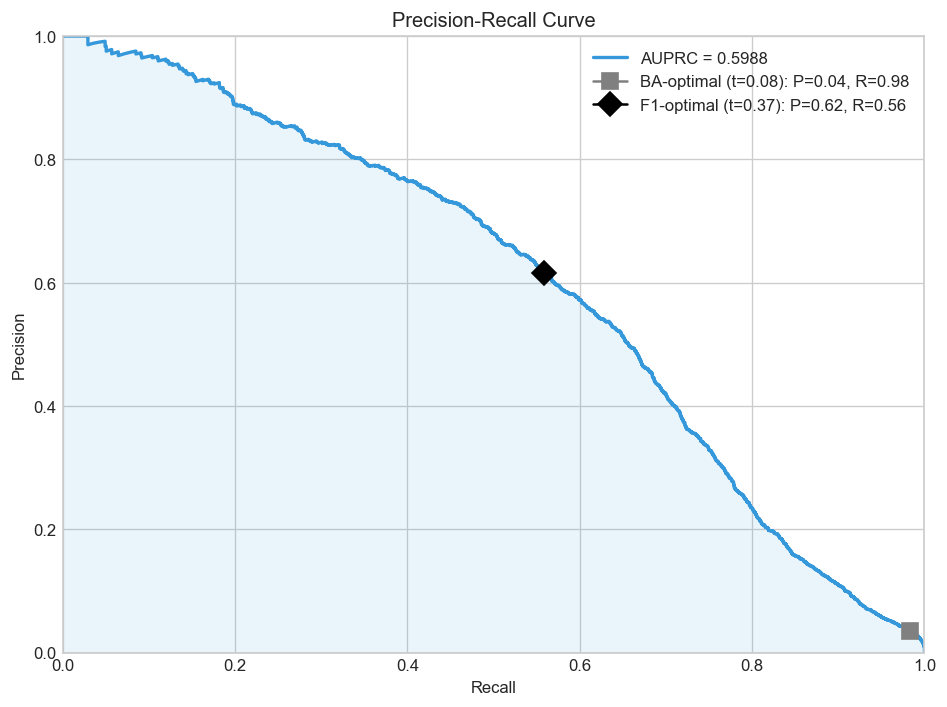

In [5]:
# Precision-Recall curve with operating points
precision, recall, thresholds = precision_recall_curve(y_val, val_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall, precision, color=LEGIT_COLOR, linewidth=2, label=f"AUPRC = {auprc:.4f}")
ax.fill_between(recall, precision, alpha=0.1, color=LEGIT_COLOR)

# Mark operating points
for t, label, color, marker in [(0.08, "BA-optimal", "gray", "s"), (0.37, "F1-optimal", "black", "D")]:
    idx = np.argmin(np.abs(thresholds - t))
    ax.plot(recall[idx], precision[idx], marker=marker, markersize=10, color=color,
            label=f"{label} (t={t}): P={precision[idx]:.2f}, R={recall[idx]:.2f}", zorder=5)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
ax.legend(loc="upper right")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

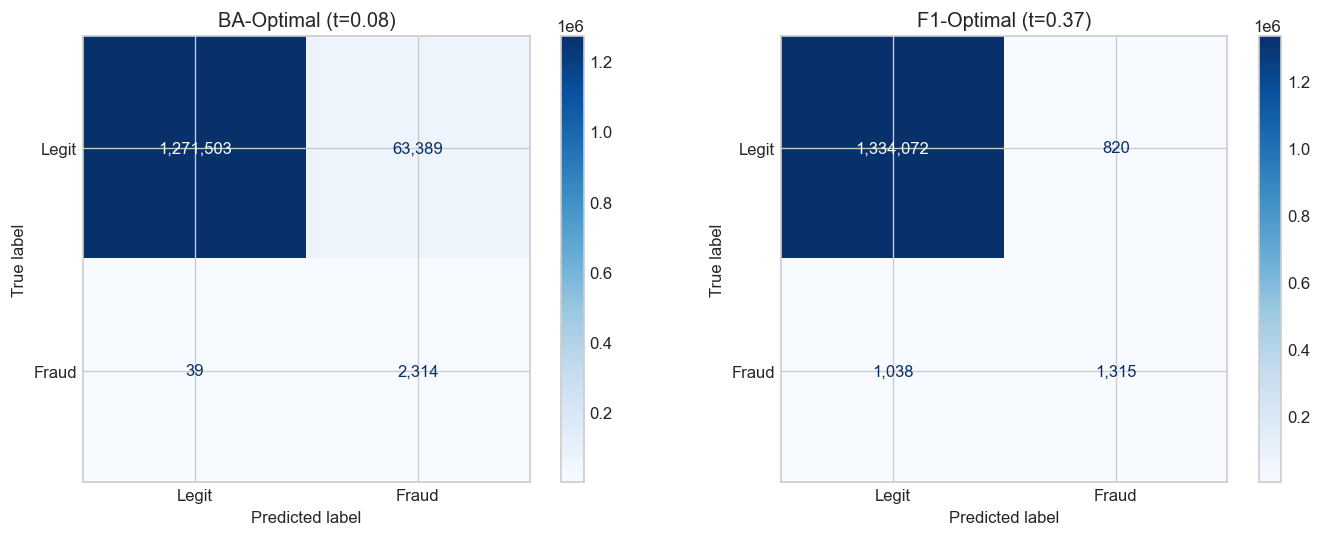

In [6]:
# Confusion matrices: BA-optimal vs F1-optimal
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, threshold, title in [
    (axes[0], 0.08, "BA-Optimal (t=0.08)"),
    (axes[1], 0.37, "F1-Optimal (t=0.37)"),
]:
    preds = (val_proba >= threshold).astype(int)
    cm = confusion_matrix(y_val, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Legit", "Fraud"])
    disp.plot(ax=ax, cmap="Blues", values_format=",")
    ax.set_title(title)

plt.tight_layout()
plt.show()

## Part B: Expense Forecasting

We retrain the direct multi-step LightGBM models (h=1, h=2, h=3) using walk-forward validation and visualize actual vs predicted expenses.

In [7]:
from src.models.predict_model import load_monthly_expenses, build_features

# Load and build features
monthly_df = load_monthly_expenses()
demo_df = pd.read_csv("data/raw/users_data.csv")
demo_df = demo_df.rename(columns={"id": "client_id"})
for col in ["per_capita_income", "yearly_income", "total_debt"]:
    if col in demo_df.columns and demo_df[col].dtype == object:
        demo_df[col] = demo_df[col].str.replace(r"[\$,]", "", regex=True).astype(float)

features_df = build_features(monthly_df, demo_df)

# Feature columns (exclude non-numeric and targets)
exclude = {"client_id", "expense_month", "total_expenses", "target_h1", "target_h2", "target_h3"}
feature_cols = [c for c in features_df.columns if c not in exclude
                and features_df[c].dtype in ["float64", "float32", "int64", "int32", "bool", "Float64", "Int64"]]

# Create targets
for h in [1, 2, 3]:
    features_df[f"target_h{h}"] = features_df.groupby("client_id")["total_expenses"].shift(-h)

# Walk-forward validation: last 8 months as test folds
months = sorted(features_df["expense_month"].unique())
test_months = months[-8:]
all_actuals, all_preds = [], []

for test_month in test_months:
    train_data = features_df[features_df["expense_month"] < test_month].dropna(subset=["target_h1"])
    test_data = features_df[features_df["expense_month"] == test_month].dropna(subset=["target_h1"])
    if len(test_data) == 0:
        continue
    m = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.03, max_depth=6, random_state=42, verbose=-1)
    m.fit(train_data[feature_cols].fillna(0), train_data["target_h1"])
    preds = m.predict(test_data[feature_cols].fillna(0))
    all_actuals.extend(test_data["target_h1"].values)
    all_preds.extend(preds)

all_actuals = np.array(all_actuals)
all_preds = np.array(all_preds)
r2 = r2_score(all_actuals, all_preds)
mae = mean_absolute_error(all_actuals, all_preds)
rmse = np.sqrt(mean_squared_error(all_actuals, all_preds))
print(f"Walk-forward R2: {r2:.4f}, MAE: ${mae:.2f}, RMSE: ${rmse:.2f}")

Walk-forward R2: 0.7639, MAE: $239.24, RMSE: $311.78


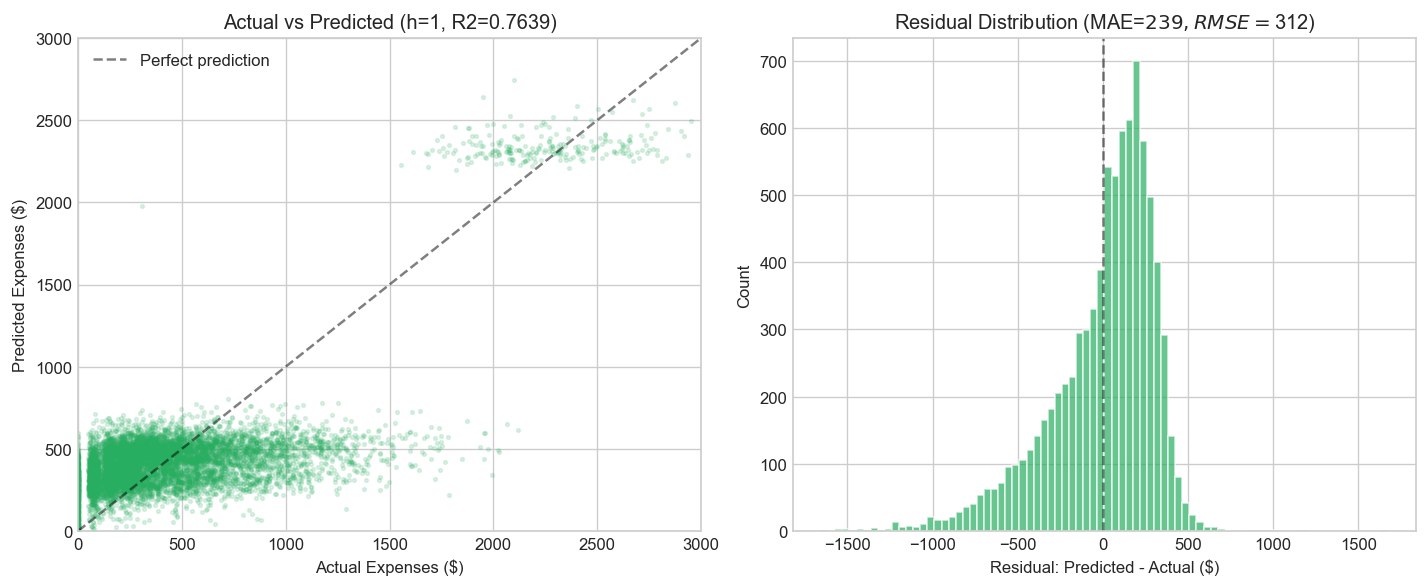

In [8]:
# Actual vs Predicted scatter + Residual histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter
max_val = max(all_actuals.max(), all_preds.max())
axes[0].scatter(all_actuals, all_preds, alpha=0.15, s=5, color=FORECAST_COLOR)
axes[0].plot([0, max_val], [0, max_val], "k--", alpha=0.5, label="Perfect prediction")
axes[0].set_xlabel("Actual Expenses ($)")
axes[0].set_ylabel("Predicted Expenses ($)")
axes[0].set_title(f"Actual vs Predicted (h=1, R2={r2:.4f})")
axes[0].legend()
axes[0].set_xlim(0, 3000)
axes[0].set_ylim(0, 3000)

# Residuals
residuals = all_preds - all_actuals
axes[1].hist(residuals, bins=80, color=FORECAST_COLOR, alpha=0.7, edgecolor="white")
axes[1].axvline(0, color="black", linestyle="--", alpha=0.5)
axes[1].set_xlabel("Residual: Predicted - Actual ($)")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Residual Distribution (MAE=${mae:.0f}, RMSE=${rmse:.0f})")

plt.tight_layout()
plt.show()

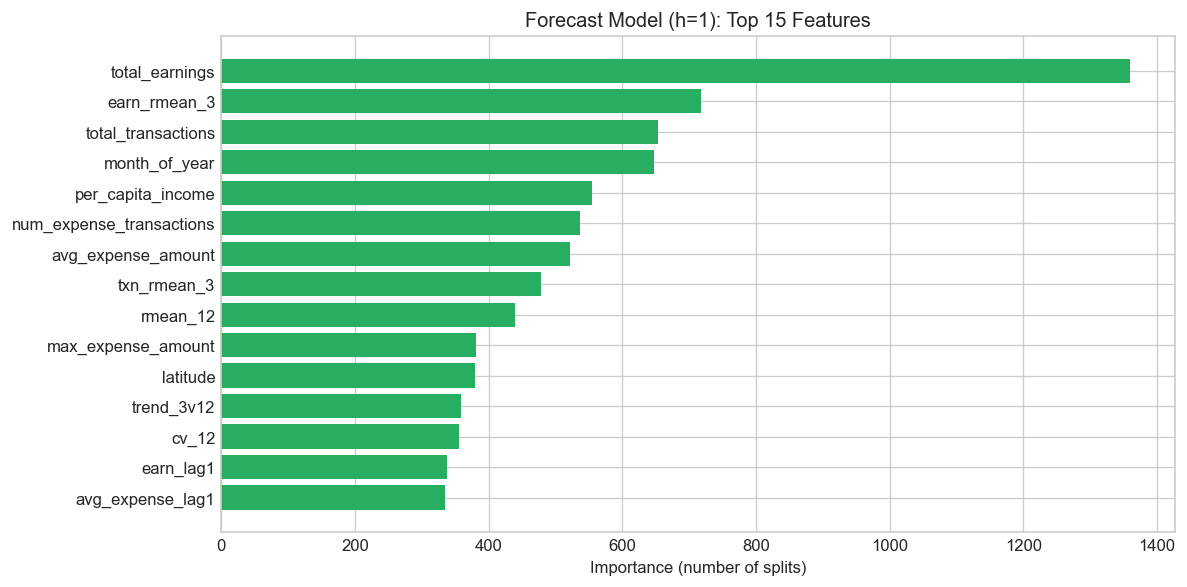

In [9]:
# Forecast feature importance (from last trained h=1 model)
f_importance = sorted(zip(feature_cols, m.feature_importances_), key=lambda x: x[1], reverse=True)[:15]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh([f[0] for f in reversed(f_importance)], [f[1] for f in reversed(f_importance)], color=FORECAST_COLOR)
ax.set_xlabel("Importance (number of splits)")
ax.set_title("Forecast Model (h=1): Top 15 Features")
plt.tight_layout()
plt.show()

## Part C: Agent Report

The AI agent generates financial reports from natural language prompts like *"Create a report for the fourth month of 2017"*. It uses a 3-layer LLM strategy (Vertex AI / Ollama / regex fallback) to extract dates, then produces earnings/expenses charts and cash flow summaries as a PDF.

The agent is tested via `make test` (3/3 tests pass). For implementation details, see the [serving guide](../docs/5-serving.md#reportgenerate).

## Summary

| Model | Metric | Value |
|-------|--------|-------|
| **Fraud Detection** | AUPRC | 0.61 |
| | Balanced Accuracy | 0.97 |
| | F1 (production) | 0.60 |
| | Precision / Recall | 0.64 / 0.57 |
| **Expense Forecast** | R2 | 0.76 |
| | MAE | ~$239 |
| | RMSE | ~$314 |
| **AI Agent** | Tests passing | 3/3 |

For the full experiment journey and design decisions behind these results, see:
- [Fraud Detection Guide](../docs/3-ml-fraud-detection.md)
- [Expense Forecast Guide](../docs/4-ml-expense-forecast.md)
- [Full Experiment Log](../experiments.md)